# Phase 4 - Setup (Data Loading & Split)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load data
ratings = pd.read_csv("ml-1m/ratings.dat", sep="::", engine="python",
                      names=["user_id", "movie_id", "rating", "timestamp"])
movies = pd.read_csv("ml-1m/movies.dat", sep="::", engine="python",
                     names=["movie_id", "title", "genres"], encoding="latin-1")
ratings.drop(columns=["timestamp"], inplace=True)

reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[["user_id", "movie_id", "rating"]], reader)
trainset, testset = train_test_split(data, test_size=0.20, random_state=42)

print("Data loaded and split.")

Data loaded and split.


# Phase 4 - Model Recreation (SVD + Hybrid)

In [12]:
# SVD
svd_model = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
svd_model.fit(trainset)
svd_predictions = svd_model.test(testset)
svd_rmse = accuracy.rmse(svd_predictions, verbose=False)

# Content-Based setup
movies["genres_clean"] = movies["genres"].str.replace("|", " ", regex=False)
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(movies["genres_clean"])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

movie_ids = movies["movie_id"].tolist()
movie_idx = {mid: i for i, mid in enumerate(movie_ids)}
user_ratings_dict = ratings.groupby("user_id").apply(
    lambda x: list(zip(x["movie_id"], x["rating"]))
).to_dict()

def cbf_score_fast(user_id, movie_id):
    if movie_id not in movie_idx:
        return 3.5
    user_hist = user_ratings_dict.get(user_id, [])
    if not user_hist:
        return 3.5
    idx = movie_idx[movie_id]
    scores = []
    for mid, r in user_hist[:50]:
        if mid in movie_idx:
            sim = cosine_sim[idx][movie_idx[mid]]
            scores.append((sim, r))
    if not scores:
        return 3.5
    scores.sort(reverse=True)
    top = scores[:10]
    total_sim = sum(s for s, _ in top)
    return sum(s * r for s, r in top) / total_sim if total_sim > 0 else 3.5

def get_alpha(user_id):
    n = len(user_ratings_dict.get(user_id, []))
    if n < 5:  return 0.0
    if n < 20: return 0.3
    if n < 50: return 0.7
    return 1.0

# Hybrid predictions
hybrid_predictions = []
for uid, iid, true_r, est, _ in svd_predictions:
    alpha = get_alpha(uid)
    cbf = cbf_score_fast(uid, iid)
    hybrid_est = alpha * est + (1 - alpha) * cbf
    hybrid_predictions.append((uid, iid, true_r, hybrid_est))

hybrid_rmse = np.sqrt(np.mean([(t - p) ** 2 for _, _, t, p in hybrid_predictions]))
print(f"SVD RMSE    : {svd_rmse:.4f}")
print(f"Hybrid RMSE : {hybrid_rmse:.4f}")

SVD RMSE    : 0.8729
Hybrid RMSE : 0.8696


# Phase 4 - Error Distribution Analysis

ERROR DISTRIBUTION ANALYSIS
Mean error (bias)   : +0.0019
Mean absolute error : 0.6822
Std of error        : 0.8696
Max overprediction  : +4.00
Max underprediction : -3.89


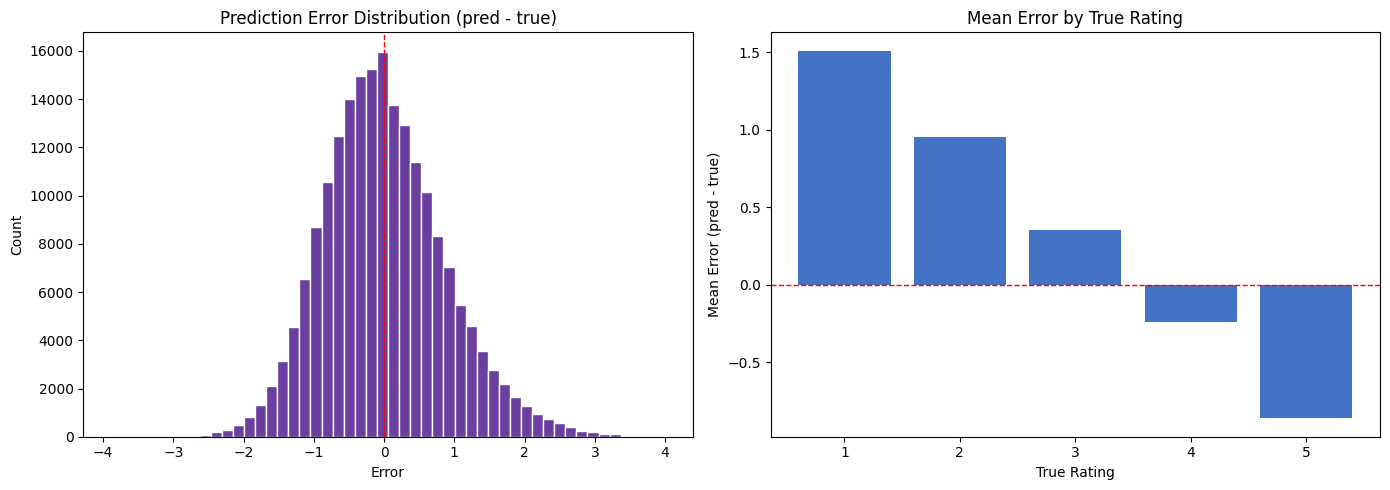

In [13]:
print("ERROR DISTRIBUTION ANALYSIS")

errors = []
for uid, iid, true_r, pred_r in hybrid_predictions:
    errors.append({
        "user_id": uid, "movie_id": iid,
        "true_rating": true_r, "pred_rating": pred_r,
        "error": pred_r - true_r, "abs_error": abs(pred_r - true_r)
    })
errors_df = pd.DataFrame(errors)

print(f"Mean error (bias)   : {errors_df['error'].mean():+.4f}")
print(f"Mean absolute error : {errors_df['abs_error'].mean():.4f}")
print(f"Std of error        : {errors_df['error'].std():.4f}")
print(f"Max overprediction  : {errors_df['error'].max():+.2f}")
print(f"Max underprediction : {errors_df['error'].min():+.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(errors_df["error"], bins=50, color="#6B3FA0", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Prediction Error Distribution (pred - true)")
axes[0].set_xlabel("Error")
axes[0].set_ylabel("Count")

avg_err_by_rating = errors_df.groupby("true_rating")["error"].mean()
axes[1].bar(avg_err_by_rating.index, avg_err_by_rating.values, color="#4472C4")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Mean Error by True Rating")
axes[1].set_xlabel("True Rating")
axes[1].set_ylabel("Mean Error (pred - true)")

plt.tight_layout()
plt.savefig("error_analysis.png", dpi=150)
plt.show()

# Phase 4 - Outlier Analysis

In [14]:
print("OUTLIER ANALYSIS")

# Worst predictions
worst = errors_df.nlargest(10, "abs_error")
worst_with_titles = worst.merge(movies[["movie_id", "title"]], on="movie_id")
print("\n10 worst predictions:")
for _, row in worst_with_titles.iterrows():
    print(f"  {row['title'][:40]:<42} true={row['true_rating']:.0f} pred={row['pred_rating']:.2f} err={row['error']:+.2f}")

# Error by user activity level
errors_df["user_n_ratings"] = errors_df["user_id"].map(
    lambda u: len(user_ratings_dict.get(u, []))
)
errors_df["activity_group"] = pd.cut(
    errors_df["user_n_ratings"],
    bins=[0, 25, 50, 100, 500, 10000],
    labels=["<25", "25-50", "50-100", "100-500", "500+"]
)
err_by_activity = errors_df.groupby("activity_group", observed=True)["abs_error"].mean()
print("\nMean absolute error by user activity:")
print(err_by_activity)

OUTLIER ANALYSIS

10 worst predictions:
  This Is Spinal Tap (1984)                  true=1 pred=5.00 err=+4.00
  Wizard of Oz, The (1939)                   true=1 pred=5.00 err=+4.00
  Dr. Strangelove or: How I Learned to Sto   true=1 pred=5.00 err=+4.00
  All About My Mother (Todo Sobre Mi Madre   true=1 pred=5.00 err=+4.00
  Boogie Nights (1997)                       true=1 pred=5.00 err=+4.00
  Killing Zoe (1994)                         true=1 pred=5.00 err=+4.00
  Army of Darkness (1993)                    true=1 pred=5.00 err=+4.00
  Dangerous Liaisons (1988)                  true=1 pred=4.95 err=+3.95
  Scary Movie (2000)                         true=5 pred=1.11 err=-3.89
  Shawshank Redemption, The (1994)           true=1 pred=4.85 err=+3.85

Mean absolute error by user activity:
activity_group
<25        0.717334
25-50      0.718660
50-100     0.718177
100-500    0.679284
500+       0.668425
Name: abs_error, dtype: float64


# Phase 4 - Model Interpretation (Feature Importance)

MODEL INTERPRETATION - GENRE FEATURE IMPORTANCE

Genre importance (mean TF-IDF weight):
drama          0.311765
comedy         0.229542
romance        0.093169
thriller       0.087547
action         0.082566
horror         0.074290
adventure      0.046373
children       0.042955
crime          0.041995
fi             0.040218
sci            0.040218
documentary    0.032290
war            0.030132
musical        0.022982
mystery        0.021470
animation      0.018844
western        0.016037
fantasy        0.012546
film           0.007171
noir           0.007171
dtype: float64


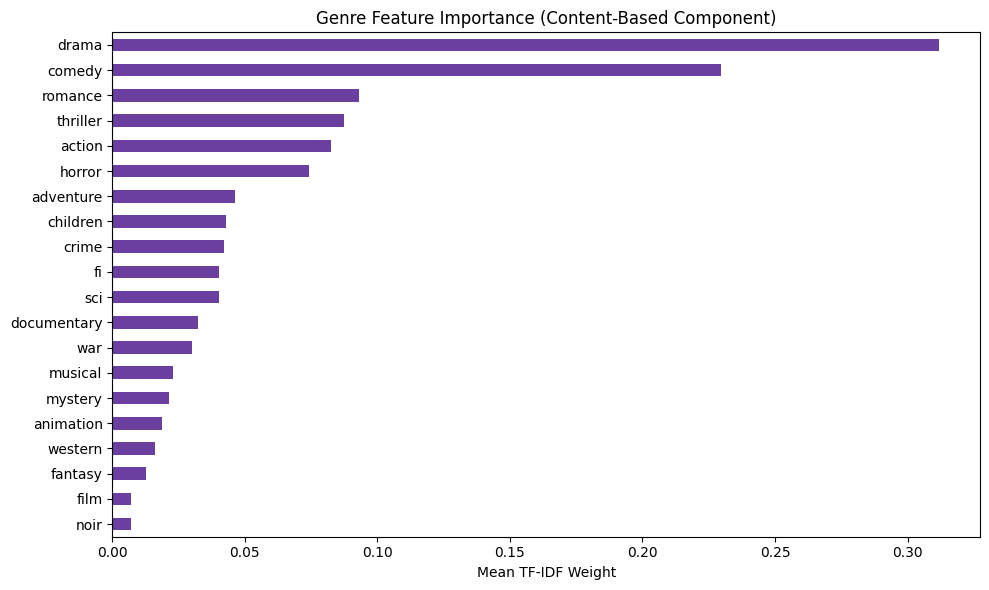

In [15]:
print("MODEL INTERPRETATION - GENRE FEATURE IMPORTANCE")

# Which genres does the content-based component rely on most?
feature_names = tfidf.get_feature_names_out()
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
genre_importance = pd.Series(mean_tfidf, index=feature_names).sort_values(ascending=False)

print("\nGenre importance (mean TF-IDF weight):")
print(genre_importance)

plt.figure(figsize=(10, 6))
genre_importance.plot(kind="barh", color="#6B3FA0")
plt.title("Genre Feature Importance (Content-Based Component)")
plt.xlabel("Mean TF-IDF Weight")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()